# Fresnel Diffraction at a Straight Edge (with Lens Magnification)

This notebook estimates the laser wavelength from straight-edge Fresnel fringes.
It converts measured fringe separations on the screen into true separations at the diffraction plane using a magnification factor, then infers lambda.

### Workflow (step by step)
1. Load and parse the transcribed experiment sheets (Notes and Main Data).
2. Normalize units to SI and build a clean analysis table.
3. Compute geometry (z) relative to the equivalent focus reference.
4. Compute primary magnification M and its uncertainty.
5. Compute theoretical Fresnel minima positions in reduced coordinate 
.
6. Convert minima differences into constants Delta v_12, Delta v_23, Delta v_34.
7. Estimate lambda per row and per minima pair.
8. Combine pair-level estimates with inverse-variance weighting.

### Why this structure
The notebook keeps both local (row-wise) and global (fit-based) estimates so you can see whether the wavelength result is stable across distance and minima pair choices.


## Setup and Parameters

This section prepares imports, finds the repo root, and loads the data file.

### Inputs you can tune
- Primary magnification is computed from the beam diameter ratio (screen/lens).
- 	hin_lens_inputs: optional independent magnification estimate from lens geometry (u, 
, 
).
- 
orce_numpy_fresnel: force NumPy integration even if SciPy is installed.
- mc_samples: Monte Carlo sample count for row-level lambda uncertainty.
- 
ng_seed: fixed seed for reproducible uncertainty values.

### Why this matters
Most sensitivity comes from magnification and spacing uncertainty, so these controls let you test assumptions without changing core code.


In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
BASE_DIR = cwd
for candidate in [cwd] + list(cwd.parents):
    if (candidate / 'experiments').exists() and (candidate / '.git').exists():
        BASE_DIR = candidate
        break
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from experiments.fresnel_straight_edge.fresnel_pipeline import (
    SCIPY_AVAILABLE,
    format_value_plus_minus,
    plot_diagnostics,
    plot_presentation_straight_line,
    print_summary,
    run_analysis,
)

DATA_PATH = BASE_DIR / 'experiments/fresnel_straight_edge/data/experimental_data_transcribed.xlsx'
assert DATA_PATH.exists(), f'Data file not found: {DATA_PATH}'

# User-tunable parameters
thin_lens_inputs = {}
force_numpy_fresnel = os.getenv('FORCE_NUMPY_FRESNEL', '0').strip() == '1'
mc_samples = 25000
rng_seed = 20260305

print(f'Repo base: {BASE_DIR}')
print(f'Data path: {DATA_PATH}')
print('SciPy available:', SCIPY_AVAILABLE)
print('force_numpy_fresnel:', force_numpy_fresnel)


Repo base: /home/shani/lazer-quest
Data path: /home/shani/lazer-quest/experiments/fresnel_straight_edge/data/experimental_data_transcribed.xlsx
SciPy available: False
force_numpy_fresnel: False


## Run Core Analysis


un_analysis(...) executes the full pipeline in one call.

### What happens inside
1. Parse note entries and measurement rows.
2. Build z, z_sigma, and cleaned Delta y columns.
3. Compute magnification from beam diameter ratio.
4. Generate Fresnel intensity curve and find first four minima.
5. Compute Delta v constants from minima spacing.
6. Compute row-level lambda and Monte Carlo uncertainties.
7. Perform weighted linear fits of (Delta x_true)^2 vs z per minima pair.
8. Convert fit slopes to pair-level lambda and combine into final value.

### Why one function
Keeping this in one pipeline ensures every table/plot in the notebook comes from the same assumptions and intermediate values.


In [2]:
results = run_analysis(
    data_path=DATA_PATH,
    thin_lens_inputs=thin_lens_inputs,
    force_numpy_fresnel=force_numpy_fresnel,
    mc_samples=mc_samples,
    rng_seed=rng_seed,
    show_plots=False,
)

print_summary(results)


Fresnel backend: numpy_trapezoid
Primary magnification M = 70 +/- 20
Thin-lens estimate not used: No thin_lens_inputs provided.
Final wavelength estimate: 400 +/- 200 nm


## Parsed Inputs and Geometry (z)

This section shows the cleaned values pulled from the Notes sheet and the derived geometry table used downstream.

### Geometry definition
z = track_position - track_focus_equivalent

Then:
- z_m = z_cm / 100
- z_sigma combines track-position and focus-reference uncertainty in quadrature.

### Why this definition
Fresnel scaling depends on propagation distance from the effective reference plane. Using the equivalent focus position aligns all rows to that same reference.

### Magnification table
The table compares:
- Diameter-ratio magnification (default for extraction).
- Primary magnification actually used.
- Optional thin-lens estimate when lens geometry is provided.


In [3]:
notes_view = results['notes_entries'][['label_raw', 'value', 'uncertainty', 'unit', 'value_m', 'uncertainty_m', 'detail_text']].copy()
mag_table = pd.DataFrame([
    {'estimate': 'Diameter ratio (screen/lens)', 'M': results['M_diameter'], 'M_sigma': results['M_diameter_sigma']},
    {'estimate': 'Primary M used in wavelength extraction', 'M': results['M_primary'], 'M_sigma': results['M_primary_sigma']},
])
if results['thin_lens_result'].get('available', False):
    mag_table = pd.concat([
        mag_table,
        pd.DataFrame([{
            'estimate': f"Thin-lens estimate ({results['thin_lens_result'].get('method')})",
            'M': results['thin_lens_result'].get('M'),
            'M_sigma': results['thin_lens_result'].get('M_sigma'),
        }]),
    ], ignore_index=True)

display(notes_view)
display(results['analysis_df'][[
    'track_position_cm', 'track_position_unc_cm',
    'z_cm', 'z_sigma_cm', 'z_m', 'z_sigma_m',
    'dy12_cm', 'dy23_cm', 'dy34_cm', 'dy_unc_cm'
]])
display(mag_table)


,label_raw,value,uncertainty,unit,value_m,uncertainty_m,detail_text
0,Focus,10.5,0.5,cm,0.1050,0.0050,cm from aperture
1,Equivalent track position,49.5,NaN,cm,0.4950,NaN,cm
2,Observation,NaN,NaN,NaN,NaN,NaN,Not significant change between different lens ...
3,Beam diameter at lens,1.5,0.5,mm,0.0015,0.0005,mm
4,Beam diameter at screen,10.0,1.0,cm,0.1000,0.0100,cm
5,Spot diameter,1.7,0.3,cm,0.0170,0.0030,cm
6,Distance between lens & screen,94.0,1.0,cm,0.9400,0.0100,cm
7,Normal screen to lens distance,495.0,4.0,cm,4.9500,0.0400,cm
8,The handwritten phrase next to 1.7 ± 0.3 cm is...,NaN,NaN,cm,NaN,NaN,


,track_position_cm,track_position_unc_cm,z_cm,z_sigma_cm,z_m,z_sigma_m,dy12_cm,dy23_cm,dy34_cm,dy_unc_cm
0,59.5,0.1,10.0,0.1,0.10,0.001,0.85,0.7,0.45,0.05
1,64.5,0.1,15.0,0.1,0.15,0.001,1.00,0.8,0.65,0.10
2,69.5,0.1,20.0,0.1,0.20,0.001,1.15,1.0,0.70,0.10
3,74.5,0.1,25.0,0.1,0.25,0.001,1.30,1.0,0.90,0.20
4,79.5,0.1,30.0,0.1,0.30,0.001,1.50,1.1,0.90,0.25
5,84.5,0.1,35.0,0.1,0.35,0.001,1.60,1.2,1.00,0.30
6,89.5,0.1,40.0,0.1,0.40,0.001,1.65,1.3,1.05,0.50


,estimate,M,M_sigma
0,Diameter ratio (screen/lens),66.666667,23.200681
1,Primary M used in wavelength extraction,66.666667,23.200681


## Fresnel Minima and Delta v

The code evaluates the straight-edge Fresnel intensity in reduced coordinate 
:

I(v) = (1/2 + C(v))^2 + (1/2 + S(v))^2

It then finds the first four minima for 
 > 0 and computes:
- Delta v_12 = v2 - v1
- Delta v_23 = v3 - v2
- Delta v_34 = v4 - v3

### Why we need Delta v
Measured fringe separations correspond to spacing between Fresnel minima indices. Delta v is the theoretical conversion factor that maps measured physical spacing to wavelength.


In [4]:
print('Fresnel backend:', results['fresnel_method'])
display(results['minima_df'])
display(results['delta_v_df'])


Fresnel backend: numpy_trapezoid


,min_index,v_min,I_min
0,1,1.872519,1.556502
1,2,2.739008,1.686324
2,3,3.391336,1.743883
3,4,3.937098,1.778128


,pair,delta_v
0,12,0.866489
1,23,0.652327
2,34,0.545763


## Wavelength Extraction

This section reports two complementary estimates.

### A) Row-wise estimate (direct formula)
For each row and each minima pair:
- Delta x_true = (Delta y_screen / 100) / M
- lambda = 2 * (Delta x_true / Delta v)^2 / z

Uncertainty is estimated via Monte Carlo by sampling Delta y, z, and M from their uncertainties.

### B) Pair-wise global fit
For each pair (12, 23, 34), fit:
- y = (Delta x_true)^2
- x = z
with weighted linear regression.

From fit slope m, compute:
- lambda_pair = 2 * m / (Delta v)^2

### Final combined wavelength
Pair-level lambda values are combined with inverse-variance weighting:
- larger-uncertainty pairs contribute less weight.

### Why both methods
Row-wise values expose local behavior/outliers; global fits reduce noise by using all rows together.


In [5]:
display(results['row_lambda_long'][[
    'z_m', 'pair', 'delta_y_cm', 'delta_x_true_m',
    'lambda_m', 'lambda_nm', 'lambda_unc_nm'
]])

display(results['global_fit_df'][[
    'pair', 'delta_v', 'lambda_nm', 'lambda_unc_nm', 'r2', 'chi2_red', 'n_points'
]])

final_summary = pd.DataFrame([
    {
        'quantity': 'Primary magnification M',
        'value +/- uncertainty': format_value_plus_minus(results['M_primary'], results['M_primary_sigma'], uncertainty_sig_figs=1),
        'unit': 'dimensionless',
    },
    {
        'quantity': 'Combined wavelength',
        'value +/- uncertainty': format_value_plus_minus(results['lambda_final_nm'], results['lambda_final_unc_nm'], uncertainty_sig_figs=1),
        'unit': 'nm',
    },
    {
        'quantity': 'Straight-line fit wavelength',
        'value +/- uncertainty': format_value_plus_minus(results['presentation_lambda_nm'], results['presentation_lambda_unc_nm'], uncertainty_sig_figs=1),
        'unit': 'nm',
    },
])
display(final_summary)

print(f"Final wavelength estimate: {format_value_plus_minus(results['lambda_final_nm'], results['lambda_final_unc_nm'], uncertainty_sig_figs=1)} nm")


,z_m,pair,delta_y_cm,delta_x_true_m,lambda_m,lambda_nm,lambda_unc_nm
0,0.10,12,0.85,0.000128,4.330362e-07,433.036236,4.044385e+07
1,0.15,12,1.00,0.000150,3.995721e-07,399.572075,1.894987e+05
2,0.20,12,1.15,0.000172,3.963256e-07,396.325552,2.739149e+05
3,0.25,12,1.30,0.000195,4.051661e-07,405.166084,6.984847e+07
4,0.30,12,1.50,0.000225,4.495186e-07,449.518584,1.779042e+06
5,0.35,12,1.60,0.000240,4.383876e-07,438.387648,2.466565e+05
6,0.40,12,1.65,0.000247,4.079381e-07,407.938115,1.437905e+05
7,0.10,23,0.70,0.000105,5.181760e-07,518.176026,3.310109e+05
8,0.15,23,0.80,0.000120,4.512009e-07,451.200893,8.589827e+07
9,0.20,23,1.00,0.000150,5.287510e-07,528.751047,3.330495e+05


,pair,delta_v,lambda_nm,lambda_unc_nm,r2,chi2_red,n_points
0,12,0.866489,416.908501,282.246715,0.988091,0.005259,7
1,23,0.652327,404.322290,322.438197,0.970653,0.009508,7
2,34,0.545763,486.569507,292.184087,0.972316,0.015792,7


,quantity,value +/- uncertainty,unit
0,Primary magnification M,70 +/- 20,dimensionless
1,Combined wavelength,400 +/- 200,nm
2,Straight-line fit wavelength,500 +/- 200,nm


Final wavelength estimate: 400 +/- 200 nm


## Required Plots

The diagnostic figure has four panels, each with a specific purpose.

1. Delta y_screen vs z:
Checks whether measured fringe spacing grows smoothly with distance.

2. (Delta x_true)^2 vs z with fit lines:
Visual check of linear model quality used to infer wavelength.

3. Row-level lambda vs z:
Shows spread and uncertainty at each distance and pair.

4. Combined lambda vs magnification M:
Sensitivity analysis that shows how strongly final wavelength depends on the magnification assumption.

### Why these plots
Together they show data quality, model fit quality, uncertainty behavior, and parameter sensitivity in one view.
5. Final straight-line presentation plot:
Combines all minima-pair points into one weighted straight-line fit and shows the final wavelength in an on-plot results box.

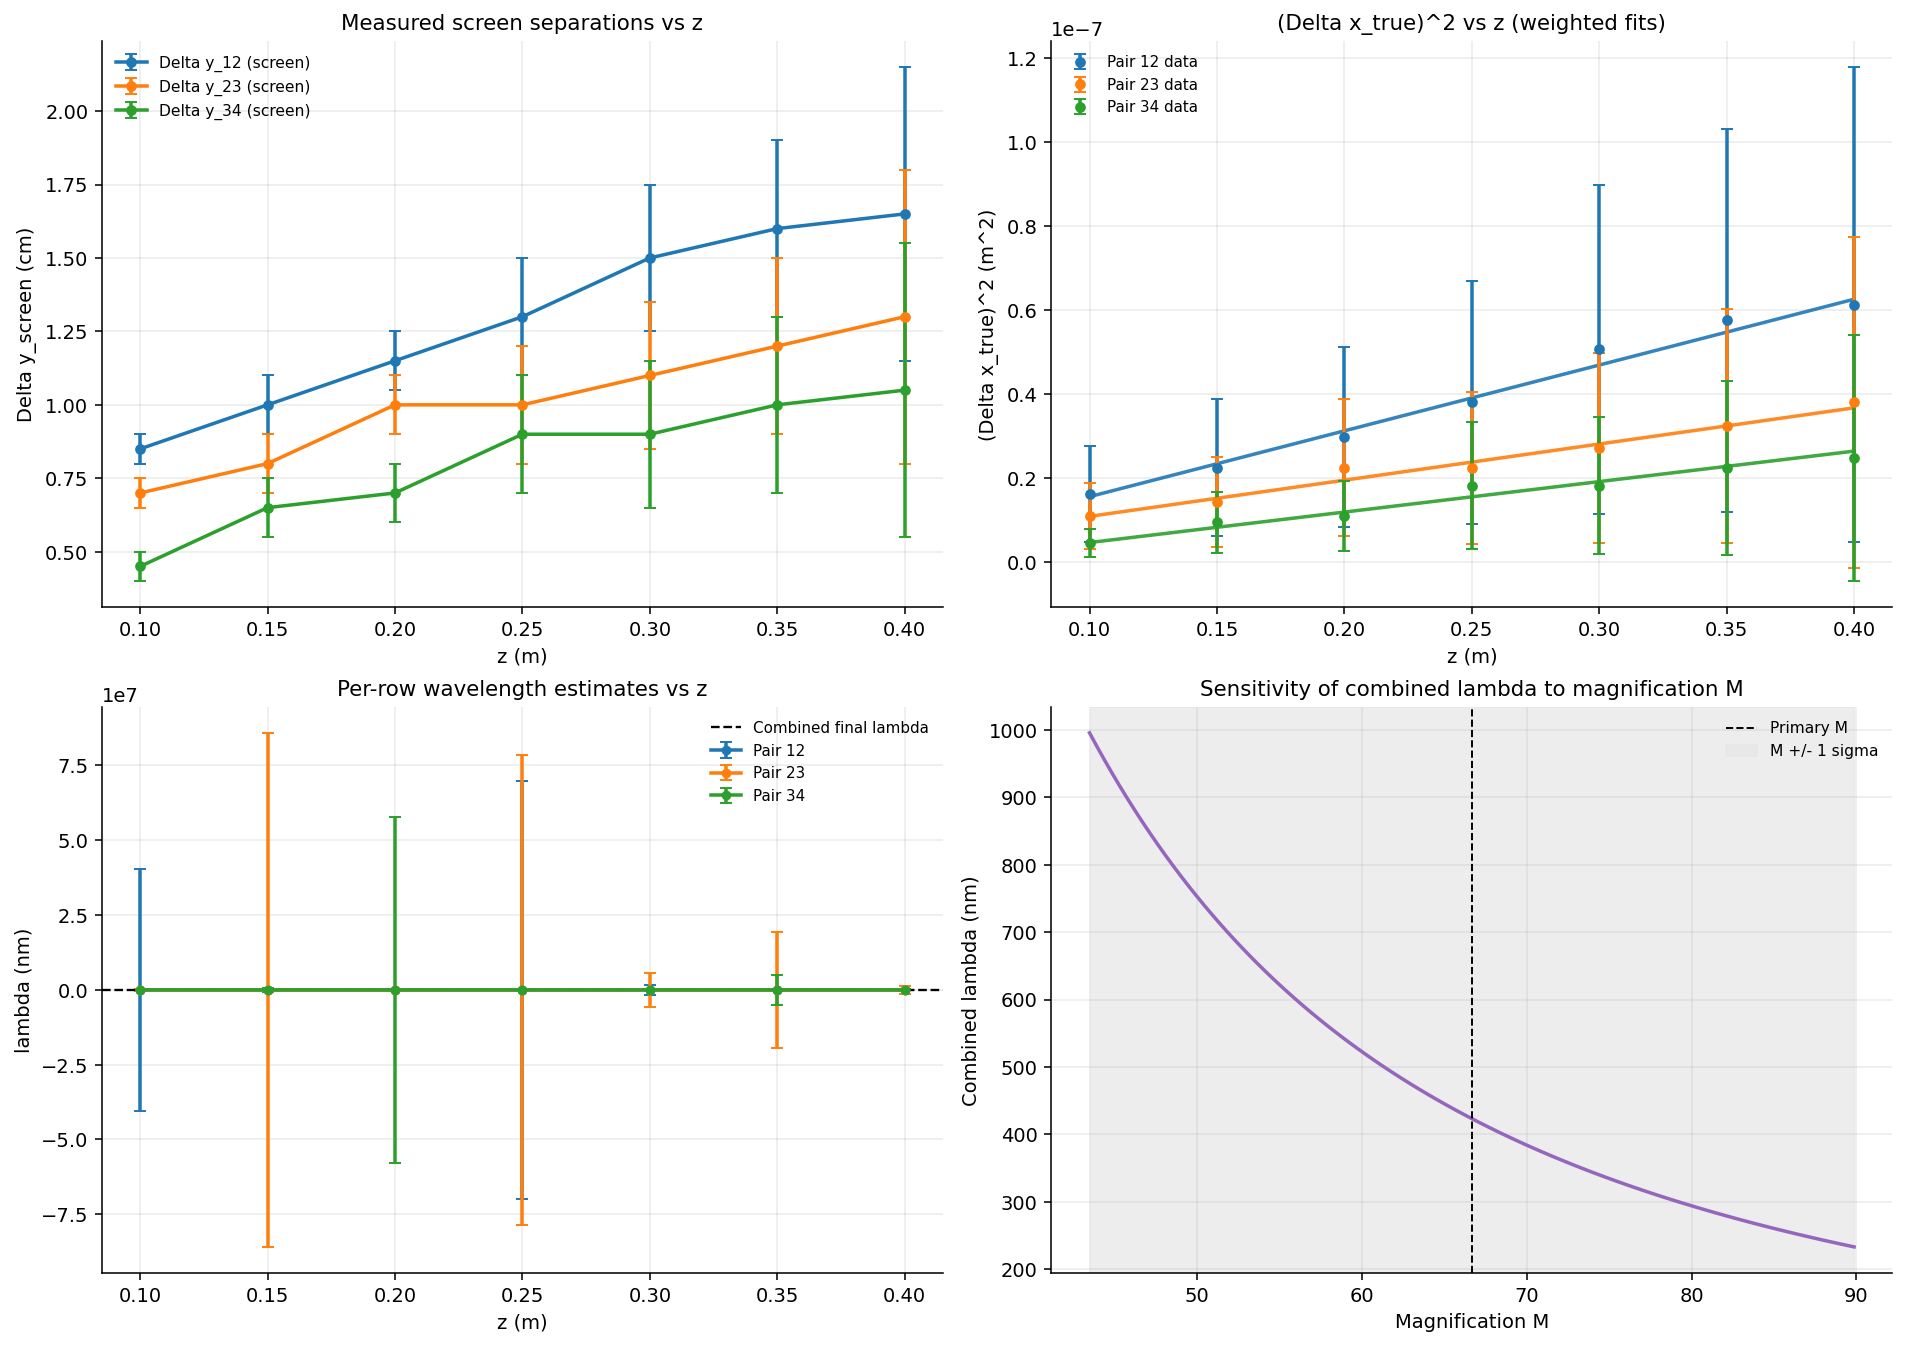

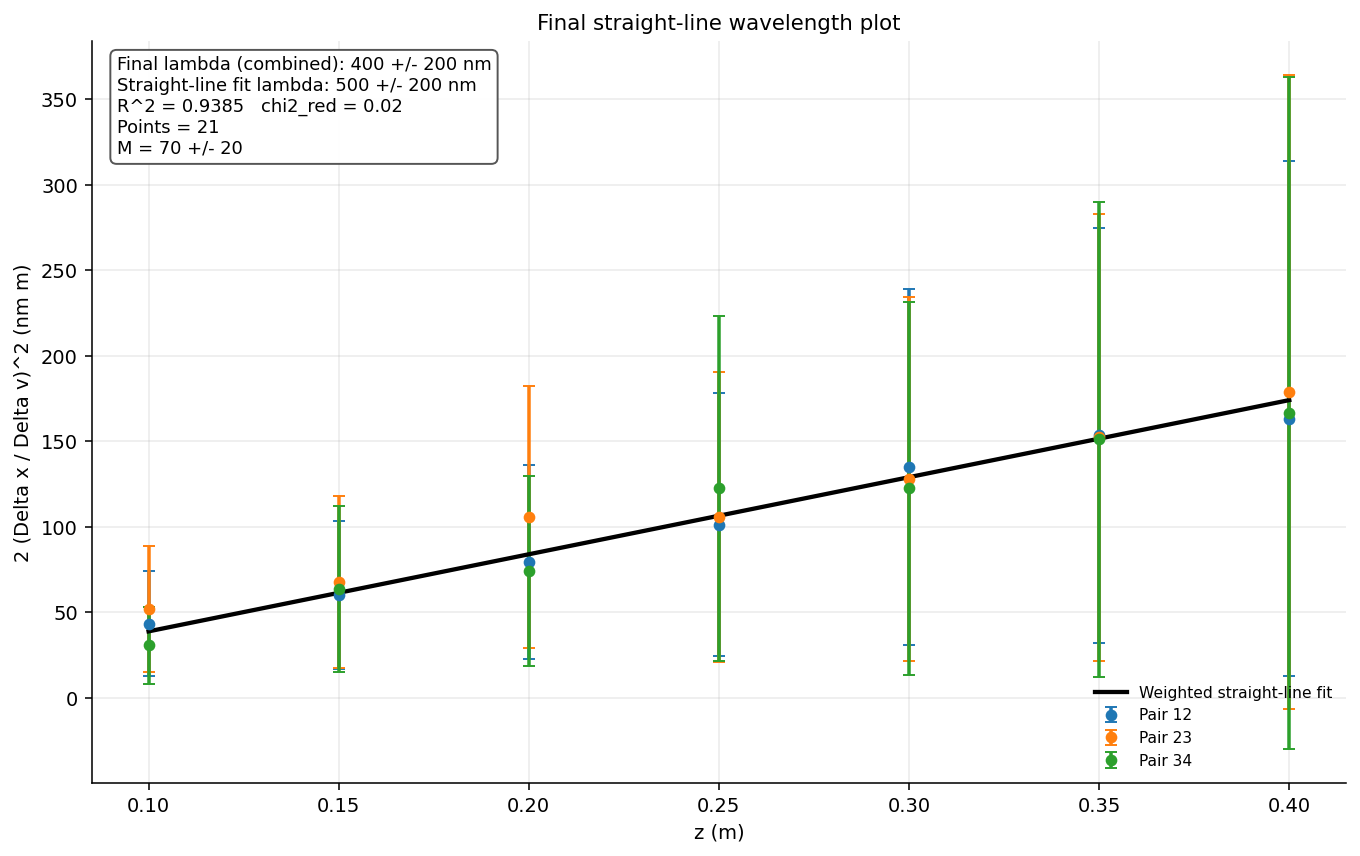

,M,lambda_nm
0,43.465986,995.751771
1,43.929999,974.827473
2,44.394013,954.555852
3,44.858026,934.910044
4,45.322040,915.864551


In [6]:
plot_diagnostics(
    analysis_df=results['analysis_df'],
    pair_specs=results['pair_specs'],
    fit_payload=results['fit_payload'],
    row_lambda_long=results['row_lambda_long'],
    lambda_final_nm=results['lambda_final_nm'],
    sensitivity_df=results['sensitivity_df'],
    M_primary=results['M_primary'],
    M_primary_sigma=results['M_primary_sigma'],
)


plot_presentation_straight_line(
    presentation_df=results['presentation_df'],
    presentation_fit=results['presentation_fit'],
    lambda_final_nm=results['lambda_final_nm'],
    lambda_final_unc_nm=results['lambda_final_unc_nm'],
    M_primary=results['M_primary'],
    M_primary_sigma=results['M_primary_sigma'],
)

display(results['sensitivity_df'].head())


## Discussion / Systematic Effects

Use this section to interpret the final number critically.

### Dominant uncertainty drivers
- Magnification uncertainty often dominates because lambda scales roughly like 1 / M^2.
- Minima-picking and finite fringe width can bias Delta y.
- Alignment/aberration can shift apparent spacing on the screen.

### Practical checks
- Compare pair-level lambda values (12, 23, 34) for consistency.
- Check whether residual spread vs z is random or trends systematically.
- Use the lambda(M) sensitivity curve to decide whether improved M calibration would materially tighten uncertainty.

### What to do next if needed
If the final uncertainty is too large, the highest leverage improvement is usually better independent calibration of M.
